# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AsserGharib1/flyrank-internshipML/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

Loads the anonymized starter file that ships with this repo. No credentials and no private data.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AsserGharib1/flyrank-internshipML"
REPO_DIR = "flyrank-internshipML"

def at_repo_root():
    return os.path.isdir("data/raw")

if IN_COLAB:
    if not at_repo_root():
        if not os.path.isdir(REPO_DIR):
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
        os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # Walk up to the repo root. Stop when the directory stops changing, which is
    # what happens at a drive root on Windows and at / on Linux.
    previous = None
    while not at_repo_root() and os.getcwd() != previous:
        previous = os.getcwd()
        os.chdir("..")

assert at_repo_root(), "Could not find data/raw. Open this from inside the repo."

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

pd.set_option("display.width", 140)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Rows:", len(df), " Columns:", df.shape[1], " Clients:", df.client_id.nunique())

Rows: 30000  Columns: 44  Clients: 32


## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

My lane is **Lane 2, Refresh and Content Opportunity Scoring**.

I picked it because it is the only lane that ends in something a person does on a Monday. FlyRank
already flags pages with hand written rules that run in production. The open gap is whether a learned
ranking can order those pages better than the rule. That gap is small enough to finish in seven weeks
and concrete enough to measure.

The other lanes are useful but do not end in a queue. Lane 1 signal analysis builds understanding.
Lane 3 clustering describes what kinds of pages exist without saying which to open first. Lane 4 on
click through rate is closer, but it answers a narrower question about one metric.

**Provisional** is the right word. I am committing to the decision, which is which page to review
first. I am not yet committing to the exact label. Section 3 shows why the obvious label does not
work, and ML-03 settles the replacement.

In [2]:
# Which lane, and how much data backs it in the starter file?

print("Lane 2, Refresh and Content Opportunity Scoring")
print()
print(f"  pages in the starter file : {len(df)}")
print(f"  pseudonymized clients     : {df.client_id.nunique()}")
print(f"  columns to work with      : {df.shape[1]}")
print()
print("Content types present:")
print(df.content_type.value_counts().head(5).to_string())

Lane 2, Refresh and Content Opportunity Scoring

  pages in the starter file : 30000
  pseudonymized clients     : 32
  columns to work with      : 44

Content types present:
content_type
keyword article       27207
feedly article         2096
comparison article      697


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

**My research question.**

> Out of thousands of published pages, which ones should a reviewer open first, and can a learned
> ranking order them better than a fixed rule?

**The decision.** Which pages go into this week's review queue, and in what order.

**Who acts.** A content editor or SEO reviewer with a fixed number of hours each week.

**What they do.** Refresh a stale page, expand a thin one, watch a strong page that has slipped, or
prune a page whose demand has gone. The queue has to suggest one of those, not just produce a score.

**Cost of a wrong call.** The two errors are not equal. A false positive costs one wasted review,
maybe an hour, and the editor moves on. A false negative costs a page that keeps fading with nobody
watching, and recovery gets harder the longer it runs.

So missing is worse than over flagging, and I would trade some precision for recall. Only up to a
point though. If the queue fills with pages that turn out fine, the editor stops trusting it and
stops opening it, and then the real precision is zero.

**What would make a recommendation wrong.** A page that dropped because a sibling page absorbed the
same demand, or because of normal seasonal movement, or because the numbers are too small to mean
anything. Those checks belong in the data contract, not in the model.

In [3]:
# Why this is a ranking problem: capacity against volume.

MIN_PRIOR_IMPRESSIONS = 100   # provisional floor. Below this, movement is mostly noise.
eligible = df[df.impressions_prev_30d >= MIN_PRIOR_IMPRESSIONS]

print(f"Pages with enough demand to be worth a look : {len(eligible)}")
print()
for per_week in (20, 50, 100):
    weeks = len(eligible) / per_week
    print(f"  at {per_week:>3} reviews a week, working through all of them takes "
          f"{weeks:,.0f} weeks, about {weeks/52:.0f} years")
print()
print("Nobody will ever reach the bottom of this list, so the order at the top is the whole job.")

Pages with enough demand to be worth a look : 18010

  at  20 reviews a week, working through all of them takes 900 weeks, about 17 years
  at  50 reviews a week, working through all of them takes 360 weeks, about 7 years
  at 100 reviews a week, working through all of them takes 180 weeks, about 3 years

Nobody will ever reach the bottom of this list, so the order at the top is the whole job.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

Three numbers, and together they make the case.

**One. 18,010 pages clear the demand floor, across 30 clients.** At 50 reviews a week that is about
seven years of work. Ordering is not a nice extra here, it is the entire problem.

**Two. About 62 percent of those pages already fell more than 20 percent.** So "it is declining" does
not narrow anything down. Most of the sample is declining. A rule that flags decline hands the editor
back most of the list, which is the same as handing back nothing. That is the honest reason a plain
rule struggles.

**Three. Only about 25 percent fell behind the typical page on their own site.** Comparing each page
to its own client cuts the field by more than half and leaves something an editor can actually work
through.

That third number is the one that convinced me the lane is worth seven weeks. There is a real
prioritisation problem here, plain decline does not solve it, and a simple comparison already makes
visible progress. Whether a model beats a tuned rule is still open, and that is what ML-07 and ML-08
are for.

**One thing I checked early.** The `trend_direction` column looks like a ready made label, but the
data dictionary defines it as a rule over two columns in the same file, down below minus 20 percent
and up above plus 20 percent. I confirmed that below. Predicting it would just recover an if
statement, so it is not my target. ML-03 defines the replacement.

In [4]:
# Number one: how big is the queue problem?
print(f"1. Pages clearing the demand floor : {len(eligible)} across {eligible.client_id.nunique()} clients")

# Number two: does plain decline narrow anything down?
mv = eligible.copy()
mv["change_pct"] = (mv.impressions_last_30d - mv.impressions_prev_30d) / mv.impressions_prev_30d * 100
plain_fall = (mv.change_pct < -20).mean()
print(f"2. Share already falling more than 20 percent : {plain_fall:.1%}")

# Number three: does comparing a page to its own site narrow it?
client_median = mv.groupby("client_id").change_pct.transform("median")
mv["gap_vs_client"] = mv.change_pct - client_median
behind_peers = (mv.gap_vs_client <= -20).mean()
print(f"3. Share falling 20 points behind their own site : {behind_peers:.1%}")
print()
print(f"   The client comparison removes {(plain_fall-behind_peers)/plain_fall:.0%} of the candidates.")

1. Pages clearing the demand floor : 18010 across 30 clients
2. Share already falling more than 20 percent : 61.6%
3. Share falling 20 points behind their own site : 25.1%

   The client comparison removes 59% of the candidates.


In [5]:
# The check that ruled out the obvious label.

valid = df.impressions_prev_30d > 0
change = (df.loc[valid, "impressions_last_30d"] - df.loc[valid, "impressions_prev_30d"]) \
         / df.loc[valid, "impressions_prev_30d"] * 100
actual_down = df.loc[valid, "trend_direction"].eq("down")
actual_up = df.loc[valid, "trend_direction"].eq("up")

print("Is `trend_direction` a measured outcome or a rule?")
print("Comparing the two series for exact equality at several cut offs:")
for t in (10, 15, 20, 25):
    print(f"  cut off {t:>2}%   down matches: {actual_down.equals(change.lt(-t))!s:<5}"
          f"  up matches: {actual_up.equals(change.gt(t))}")
print()
print("Only 20 matches, which is what the data dictionary states.")
print("So it is a rule over two columns in the same file, not something anyone measured.")

Is `trend_direction` a measured outcome or a rule?
Comparing the two series for exact equality at several cut offs:
  cut off 10%   down matches: False  up matches: False
  cut off 15%   down matches: False  up matches: False
  cut off 20%   down matches: True   up matches: True
  cut off 25%   down matches: False  up matches: False

Only 20 matches, which is what the data dictionary states.
So it is a rule over two columns in the same file, not something anyone measured.


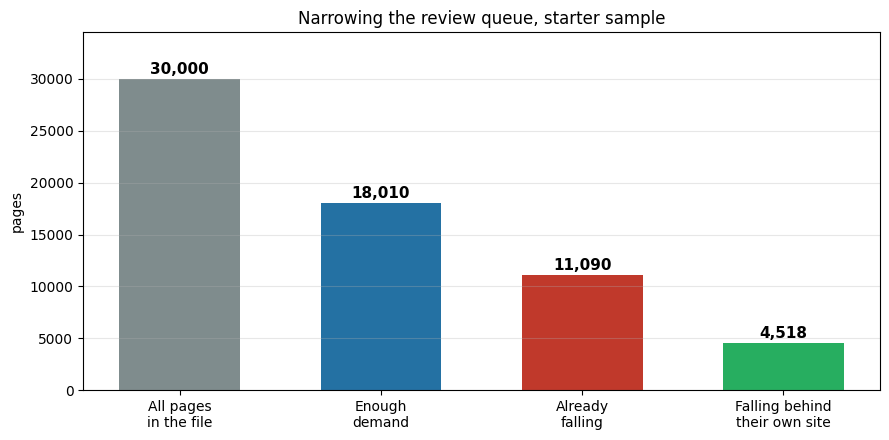

Plain decline barely narrows the list. Comparing each page to its own site does.


In [6]:
# The three numbers as one picture.

steps = ["All pages\nin the file", "Enough\ndemand", "Already\nfalling", "Falling behind\ntheir own site"]
values = [len(df), len(eligible), int((mv.change_pct < -20).sum()), int((mv.gap_vs_client <= -20).sum())]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(steps, values, color=["#7f8c8d", "#2471a3", "#c0392b", "#27ae60"], width=0.6)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 500, f"{v:,}", ha="center",
            fontsize=11, fontweight="bold")
ax.set_ylabel("pages")
ax.set_title("Narrowing the review queue, starter sample", fontsize=12)
ax.set_ylim(0, len(df) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Plain decline barely narrows the list. Comparing each page to its own site does.")

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

**What I will be able to say.**

* I observed these patterns in one anonymized sample of 30,000 pages across 30 pseudonymized clients.
* Certain signals were associated with pages falling behind their peers, measured in a later window.
* A ranking built on those signals scored a certain precision at 50, compared against a rule baseline
  on the same split.
* The output supports a decision. It tells a reviewer where to look first, given limited hours.

**What I will never be able to say.**

* That refreshing a page caused it to recover. Proving that needs an experiment or a causal design,
  and this data has neither.
* That I predicted or reverse engineered how Google ranks pages. I only see impressions, clicks,
  position and sessions after the fact.
* That a flagged page is guaranteed to be worth fixing. The queue is a shortlist for a human, not a
  verdict.
* Anything about a specific client, domain, address or search term. Those were removed before I got
  the data and my outputs will not reconstruct them.

**Words I will use.** Observed, measured, associated with, directional, provisional, decision
support.

**Words I will avoid.** Proves, causes, guarantees, predicts Google, semantic clustering when the
data has no text.

**How I will keep myself honest.** Every number I write in a sentence has to come from a cell in the
same notebook. If I cannot point at the output, the sentence comes out.

In [7]:
# A claim I can make, and the same claim overstated, side by side.

# The population has to match the number. This claim is about the pages that
# cleared the demand floor, not the whole file.
n_rows, n_clients = len(mv), mv.client_id.nunique()

print("SAFE, and backed by a cell in this notebook:")
print(f'  "Among the {n_rows:,} pages in this sample that cleared a 100 impression floor,')
print(f'   across {n_clients} pseudonymized clients, {plain_fall:.0%} had already fallen more than')
print('   20 percent, so decline on its own does not identify which pages need attention."')
print()
print("NOT SAFE, and I will not write this:")
print('  "Most pages decline because they are stale, and refreshing them recovers traffic."')
print("   Nothing here measures why a page fell, and nothing measures what happens after an edit.")
print()
print("Public safety check on this notebook's output:")
for col in ("client_id", "content_id"):
    print(f"  {col} sample value: {df[col].iloc[0]}  (scrambled code, not a real name)")
print("  no domains, addresses, titles or search terms are printed anywhere above")

SAFE, and backed by a cell in this notebook:
  "Among the 18,010 pages in this sample that cleared a 100 impression floor,
   across 30 pseudonymized clients, 62% had already fallen more than
   20 percent, so decline on its own does not identify which pages need attention."

NOT SAFE, and I will not write this:
  "Most pages decline because they are stale, and refreshing them recovers traffic."
   Nothing here measures why a page fell, and nothing measures what happens after an edit.

Public safety check on this notebook's output:
  client_id sample value: client_f369cb89fc  (scrambled code, not a real name)
  content_id sample value: content_304f48230142  (scrambled code, not a real name)
  no domains, addresses, titles or search terms are printed anywhere above


## Self-check

Before you submit, confirm each line honestly:

* [x] Every section above is filled, thinking written out and code that backs it
* [x] The notebook runs top to bottom with no errors (Runtime, then Run all)
* [x] No client names, web addresses, or private search terms anywhere
* [x] My claims stay careful. Observed, measured, provisional, decision support
* [x] Committed under `work/notebooks/`, then submit the repo URL on the card